# Thermostaat

In het vorige werkblad heb je gezien hoe een gas zich gedraagt in een zuiger waarbinnen wordt voldaan aan de wet van behoud van energie. In dat geval geldt $p \propto \alpha V^{-k}$, waarbij $k$ een exponent is die wordt bepaald door de vrijheidsgraden van het gas. In eerste instantie had je kunnen verwachten dat de grafiek de ideale gaswet zou volgen. De temperatuur van het gas verandert echter door de werking van de zuiger. 

We gaan de simulatie nu uitbreiden met de mogelijkheid om warmte aan en af te voeren uit het controlevolume. Op die manier kunnen we ook isotherme simulaties doen.

Eerst herhalen we de nodige ingrdienten:

   klasse voor het deeltje met bijbehorende functies
- variabelen en randcondities van controle volume
- functies voor een lijst deeltjes

Daarna voegen we de code toe voor het warmtecontact:

- introduceren thermostaat
- bestuderen isotherm proces

## Laden van eerdere code

De pakketten van Python en de constanten voor de simulatie:



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

BOX_SIZE_0 = 10                # Hoogte en breedte startvolume
N = 40                         # Aantal deeltjes
V_0 = 1                        # Startsnelheid van deeltjes
RADIUS = 0.1                   # Straal van moleculen
DT = 0.3 * RADIUS / V_0        # Tijdstap om geen botsing te missen
V_PISTON_0 = -0.1              # Startsnelheid van zuiger 
# (negatief betekent zowel links als rechts naar binnen gericht)

De klasse voor het gasmolecuul met de interacties:

In [15]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)


def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    r1, r2 = p1.r, p2.r
    v1, v2 = p1.v, p2.v
    m1, m2 = p1.m, p2.m
    delta_r = r1 - r2
    delta_v = v1 - v2
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if np.dot(delta_r, delta_v) > 0:
        return
    distance_squared = np.dot(delta_r, delta_r) + 1e-12  # voorkom deling door 0
    # Botsing oplossen volgens elastische botsing in 2D
    v1_new = v1 - 2 * m2 / (m1 + m2) * np.dot(delta_v, delta_r) / distance_squared * delta_r
    v2_new = v2 - 2 * m1 / (m1 + m2) * np.dot(-delta_v, -delta_r) / distance_squared * (-delta_r)
    p1.v = v1_new
    p2.v = v2_new

De randvoorwaarde van het volume. Hierbij is rekening gehouden met een bewegende zuiger die in het vorige werkblad is toegevoegd.

In [16]:
def box_collision(particle: ParticleClass):
    """ botsing met harde wanden bij bewegende zuiger """
    global box_length, box_height, v_piston    
    if particle.r[0] + particle.R > box_length / 2:
        particle.v[0] = -particle.v[0] + 2*v_piston
        particle.r[0] = box_length/2 - particle.R             
    elif particle.r[0] - particle.R < -box_length / 2:
        particle.v[0] = -particle.v[0] - 2*v_piston
        particle.r[0] = -box_length/2 + particle.R              
    if abs(particle.r[1]) + particle.R > box_height / 2: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R) 

De functies voor het uitvoeren van de functies over de gehele lijst met deeltjes, waarbij we de werking van de zuiger ook hebben meegenomen:

In [17]:
def create_particles(particles):
    """ Leegmaken en opnieuw aanmaken van deeltjes  in lijst """
    global box_length, box_height
    particles.clear()
    for _ in range(N):
        vx = np.random.uniform(-V_0, V_0)
        vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
        x = np.random.uniform(-box_length/2 + RADIUS, box_length/2 - RADIUS)
        y = np.random.uniform(-box_height/2 + RADIUS, box_height/2 - RADIUS)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=[x, y], R=RADIUS))
    
def temperature(particles) -> float:
    temp = 0.0
    for p in particles:
        temp += p.kin_energy
    temp = temp / len(particles)
    return temp
        
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    ignore_list = []
    for p1 in particles:
        if p1 in ignore_list:                                   # overslaan als partner al geweest is
            continue
        for p2 in particles:
            if p1 is p2:
                continue
            if collide_detection(p1, p2):
                particle_collision(p1, p2)
                ignore_list.append(p2)                          # partner uitsluiten van de berekening

def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en bepaling druk """
    global pressure, box_length, box_height, work     # om pressure buiten de functie te kunnen gebruiken
    total_impulse = np.zeros(2, dtype=float)    # totale stoot op wanden per richting
    for p in particles:
        momentum_old = p.momentum.copy()
        box_collision(p)
        impulse = p.momentum - momentum_old 
        total_impulse += abs(impulse) # stoot is altijd netjes loodrecht naar buiten
    pressure = 0.95 * pressure + 0.05 * sum(total_impulse) / ((2 * box_length + 2 * box_height) * DT) 
    work -= total_impulse[0] * v_piston # negatieve v_piston is naar binnen en verhoogt de arbeid
    
def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    global box_length
    box_length += 2 * v_piston * DT # zowel links als rechts zuiger
    for p in particles:
        p.update_position()
    handle_walls(particles)  
    handle_collisions(particles)

## Test code

Voordat we de code aanpassen controleren we eerst of alles het doet. Hiervoor maken we zowel een P,V-diagram als een T,V-diagram tijdens de werking van de zuiger:

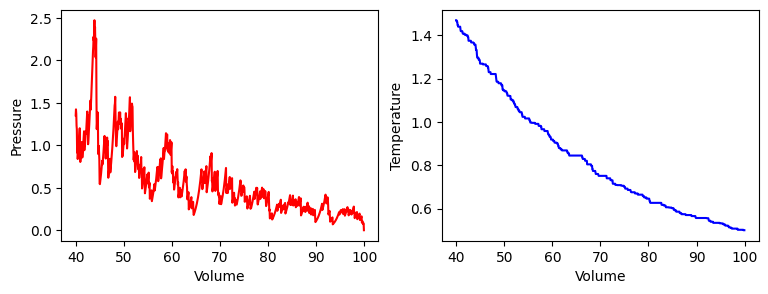

In [ ]:
particles = []
volumes = np.zeros(1000, dtype=float)
pressures = np.zeros(1000, dtype=float)
temperatures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_height = BOX_SIZE_0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    pressures[i] = pressure
    temperatures[i] = temperature(particles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes, pressures, '-r')
ax2.plot(volumes, temperatures, '-b')

plt.show()

We zien inderdaad de druk, $P \propto V^{-k}$, met een exponent $k > 1$, wat verklaard wordt door de toename van de temperatuur tijdens het proces. In dit werkblad gaan we nu proberen de temperatuur van het gas constant te houden. We kunnen dan controleren of de druk inderdaad invers proportioneel is met het volume. 

## De thermostaat

In de werkelijkheid is de temperatuur van de wand een mate van de amplitude van de trillingen van de deeltjes waaruit de wand bestaat. De wederzijdse overdracht van de energie van die trillingen naar de kinetische energie van de gasmoleculen bepaalt het thermische contact tussen de wanden van het controlevolume en het gas. In ons model bestaat de wand echter helemaal niet uit deeltjes, maar hebben we een denkbeeldige lijn getrokken in de ruimte. We moeten daarom een wiskundige truc toepassen om temperatuur van het gas te beïnvloeden. 

Er zijn in de literatuur verschillende van dit soort trucs bedacht. Ze worden een 'thermostaat' genoemd en hebben allemaal hun voor- en nadelen. In ons geval houden we het simpel: Op het moment dat een gasmolecuul botst met de wand die een thermisch contact voorstelt, dan schalen we de snelheid van dit molecuul met (de wortel van) de verhouding tussen de veronderstelde temperatuur van de wand en de temperatuur die het gas op dat moment heeft. Voor het gemak houden we de zuiger links en rechts van het volume en maken we het thermische contact aan de onder- en bovenwand.

In [19]:
def box_collision(particle: ParticleClass):
    """ botsing met harde wanden bij bewegende zuiger """
    global box_length, box_height, v_piston, set_temp    
    if particle.r[0] + particle.R > box_length / 2:
        particle.v[0] = -particle.v[0] + 2*v_piston
        particle.r[0] = box_length/2 - particle.R             
    elif particle.r[0] - particle.R < -box_length / 2:
        particle.v[0] = -particle.v[0] - 2*v_piston
        particle.r[0] = -box_length/2 + particle.R              
    if abs(particle.r[1]) + particle.R > box_height / 2: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R) 
        particle.v *= (set_temp/temperature(particles))**0.5

Voor de functie `handle_walls` moeten we nu de berekening aanpassen om zowel de arbeid (door de zuigerwand) als de warmtestroom (door de overige wanden) te berekenen.

In [20]:
def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en bepaling druk """
    global pressure, box_length, box_height, work, heat     # om pressure buiten de functie te kunnen gebruiken
    outward_impulse = np.zeros(2, dtype=float)
    tot_out_impulse = np.zeros(2, dtype=float)
    for p in particles:
        momentum_old = p.momentum.copy()
        energy_old = p.kin_energy
        box_collision(p)
        if p.r[0] + p.R >= box_length / 2:
            outward_impulse[0] = -p.momentum[0] + momentum_old[0]
        elif p.r[0] - p.R <= -box_length / 2:
            outward_impulse[0] = p.momentum[0] - momentum_old[0]
        else:
            outward_impulse[0] = 0.0
        if p.r[1] + p.R >= box_height / 2:
            outward_impulse[1] = -p.momentum[1] + momentum_old[1]
        elif p.r[1] - p.R <= -box_height / 2:
            outward_impulse[1] = p.momentum[1] - momentum_old[1]
        else:
            outward_impulse[1] = 0.0
        tot_out_impulse += abs(outward_impulse) # stoot is altijd netjes loodrecht naar buiten
        heat += energy_old * (p.momentum[1]**2 - momentum_old[1]**2) / momentum_old[1]**2
    pressure = 0.95 * pressure + 0.05 * sum(tot_out_impulse) / ((2 * box_length + 2 * box_height) * DT) 
    work += tot_out_impulse[0] * v_piston # negatieve v_piston is naar binnen en verlaagt de arbeid

Met deze nieuwe definitie van de functies, draaien we een simulatie waarin we zowel de temperatuur als de druk plotten als functie van het volume. Let op dat deze simulatie een veel groter aantal tijdstappen bevat. Daarom zal deze simulatie ook langer duren. Maak je geen zorgen als het een minuut duurt om de berekening te voltooien.

Om verdere belasting van de servers tot een minimum te beperken, berekent deze simulatie ook alvast de totale warmte $Q$ en de totale arbeid $W$ tijdens het proces. Deze worden opgeslagen in de arrays `heats` en `works`. We zullen de resultaten van deze simulatie voor een aantal vervolgstappen gebruiken. 

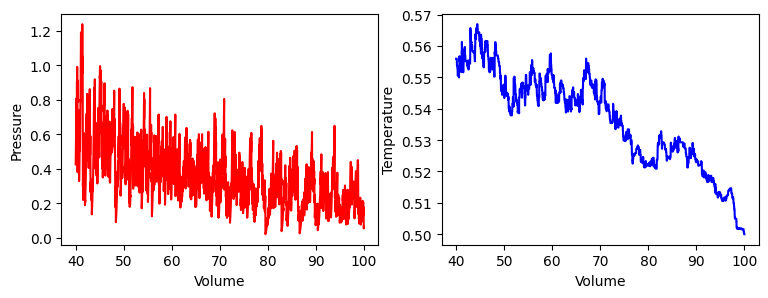

In [21]:
#VOORBEELDUITWERKING

particles = []
volumes = np.zeros(5000, dtype=float)
pressures = np.zeros(5000, dtype=float)
temperatures = np.zeros(5000, dtype=float)
heats = np.zeros(5000, dtype=float)
works = np.zeros(5000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
heat = 0.0
box_height = BOX_SIZE_0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = 0.2 * V_PISTON_0
create_particles(particles)     # resetten deeltjes 
set_temp = temperature(particles)
for i in range(5000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    pressures[i] = pressure
    temperatures[i] = temperature(particles)
    heats[i] = heat
    works[i] = work


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes, pressures, '-r')
ax2.plot(volumes, temperatures, '-b')


plt.show()

```{exercise}
Maak een fit van het P,V-diagram uit de laatste simulatie. (Maak dus niet een nieuwe simulatie, maar gebruik de gegevens van de vorige) De fit-functie hiervoor is alvast gegeven.
```

In [ ]:
def power_law(vol, a, n):
    return a * vol**n    

# RUIMTE VOOR VERDERE UITWERKING

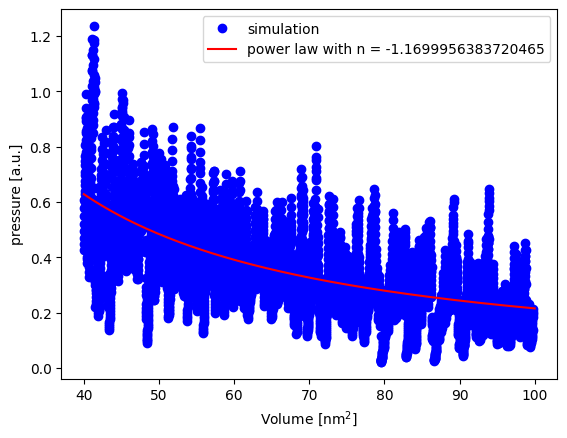

In [22]:
# VOORBEELDUITWERKING

def power_law(vol, a, n):
    return a * vol**n    

# we fitten de eerste 20 punten niet mee in verband met de integrator vd druk
popt, pocv = curve_fit(power_law, volumes[20:], pressures[20:])

x_fit = volumes
y_fit = power_law(x_fit, *popt)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('pressure [a.u.]')

plt.plot(volumes[20:], pressures[20:], 'bo', label='simulation')
plt.plot(x_fit, y_fit, 'r-', label='power law with n = ' + str(popt[1]))

plt.legend()

plt.show()

Je ziet dat de exponent van dit P,V-diagram net niet overeenkomt met de ideale verwachting. 

```{exercise}
Het P,V-diagram is niet perfect invers proportioneel door de verandering van de temperatuur. Verklaar dat de temperatuur nooit helemaal terugkeert naar de beginwaarde vanuit de dynamische beweging van de gasmoleculen.
```

Als je goed kijkt zie je dat de temperatuur voor kleinere volumes een steeds grotere afwijking vertoont. 

```{exercise}
Als je ervan uit kan gaan dat de afvoer van warmte evenredig is met het verschil tussen de starttemperatuur en de actuele temperatuur, verklaar dan waarom de temperatuur toeneemt voor kleine volumes.
```

Al met al lijkt het resultaat van de simulatie er redelijk uit te zien. Maar om een sterke indicatie te hebben dat dit zo is, moeten we weer een goede test verzinnen om de simulatie te verifiëren. In dit geval kunnen we controleren of de simulatie voldoet aan de eerste hoofdwet.

```{exercise}
Maak een grafiek die helder zichtbaar maakt dat de simulatie inderdaad voldoet aan de eerste hoofdwet (of niet). Als de code hierboven nog klopt, zijn de tekens in overeenstemming met de definitie van het boek.
```

In [ ]:
### RUIMTE VOOR UITWERKING

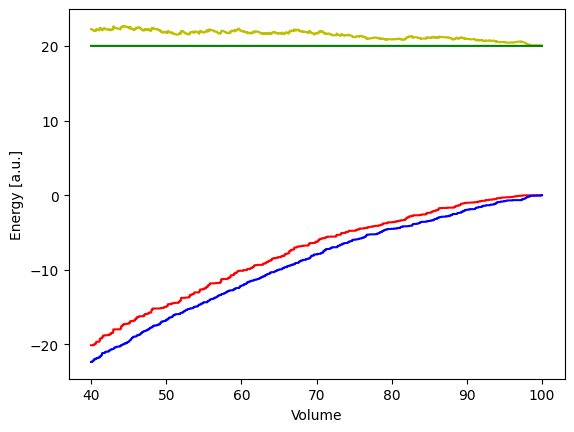

In [ ]:
## VOORBEELDUITWERKING

plt.figure()
plt.xlabel('Volume')
plt.ylabel('Energy [a.u.]')

energies = int(N) * temperatures + works - heats

plt.plot(volumes, heats, '-r')
plt.plot(volumes, works, '-b')
plt.plot(volumes, int(N) * temperatures, '-y')
plt.plot(volumes, energies, '-g')

plt.show()

In het boek wordt uitgelegd dat er maar twee vormen van energieoverdracht zijn van een systeem naar de omgeving. Dit kan via warmteoverdracht of via arbeid. Bijzonder is dat deze beide grootheden alleen de snelheid van de moleculen beïnvloeden. Toch zullen we in het volgende werkblad zien dat er een fundamenteel verschil zit in de werking van deze twee macroscopische grootheden. 

```{exercise}
Laat je werkblad door een TA aftekenen
```